In [150]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltools.stats import regress
from nltools.external import glover_hrf

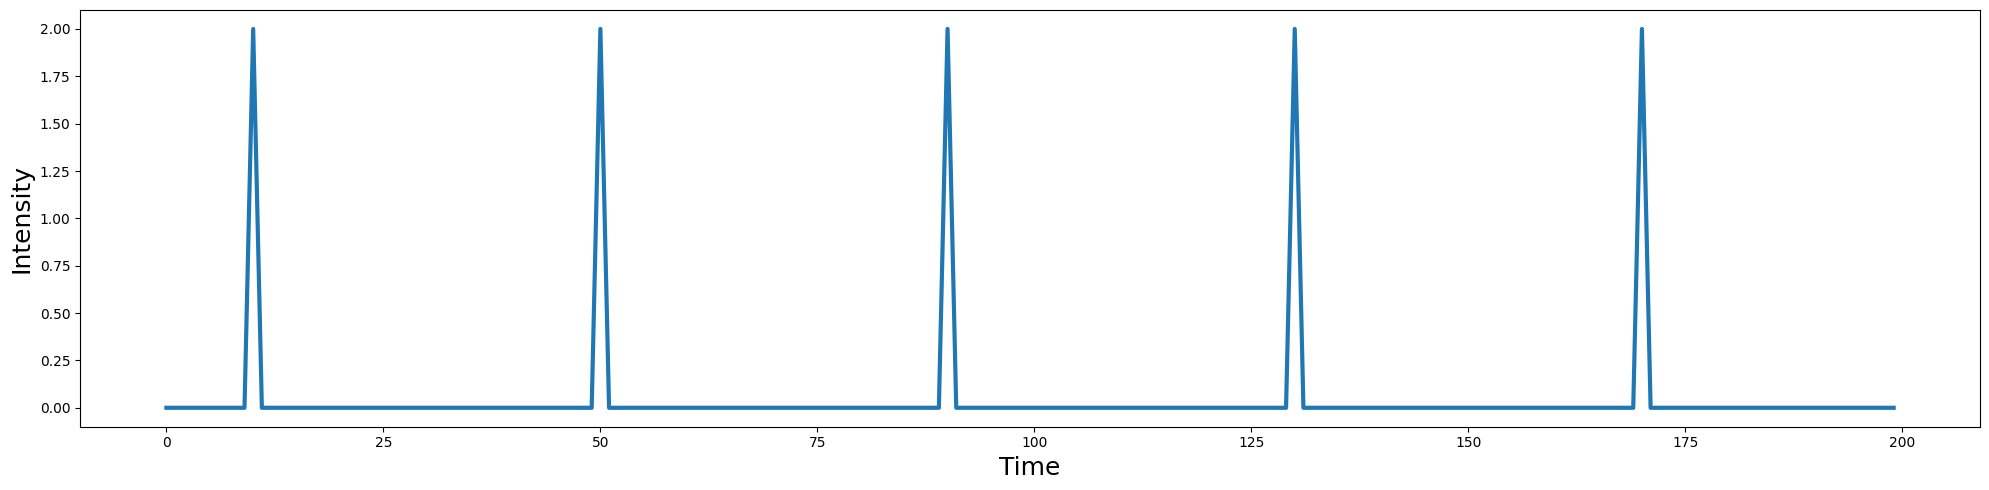

In [151]:
n_tr = 200
n_trial = 5
face = np.zeros(n_tr)
face[np.arange(10, n_tr, int(n_tr/n_trial))] = face_intensity
# face is a numpy array of zeros. First 1 is the 10th index, then every 20th element until index 200
# np arange = range()

#each column is a different signal
def plot_timeseries(data, labels=None, linewidth=3):
    '''Plot a timeseries
    
    Args:
        data: (np.ndarray) signal varying over time, where each column is a different signal.
        labels: (list) labels which need to correspond to the number of columns.
        linewidth: (int) thickness of line
    '''
    plt.figure(figsize=(20,5))
    plt.plot(data, linewidth=linewidth)
    plt.ylabel('Intensity', fontsize=18)
    plt.xlabel('Time', fontsize=18)
    plt.tight_layout()
    if labels is not None:
        if len(labels) != data.shape[1]:
            raise ValueError('Need to have the same number of labels as columns in data.')
        plt.legend(labels, fontsize=18)
    
plot_timeseries(face)


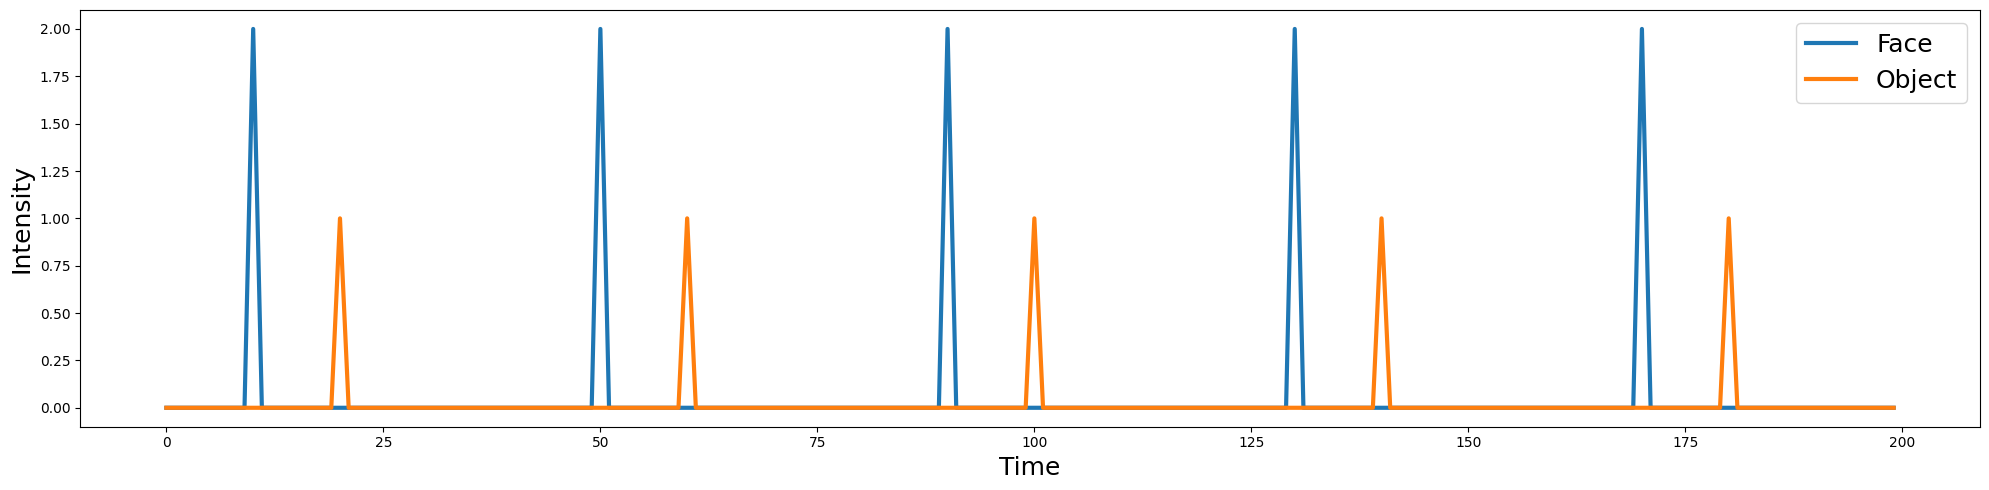

In [152]:
face_intensity=2
object_intensity=1
n_tr = 200
n_trial = 5
face = np.zeros(n_tr)
face[np.arange(10, n_tr, int(n_tr/n_trial))] = face_intensity
obj = np.zeros(n_tr)
obj[np.arange(20, n_tr, int(n_tr/n_trial))] = object_intensity
voxel = np.vstack([face,obj]).T # stack arrays vertically (new array's 1st axis dimension is larger 
# each previous array added as new rows(rows))

plot_timeseries(voxel, labels=['Face', 'Object'])

Text(0.5, 0, 'Time')

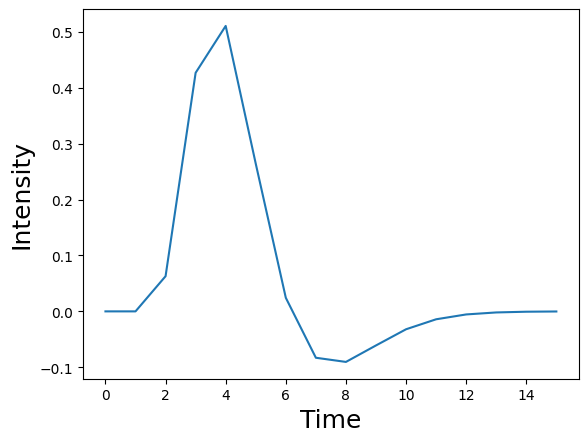

In [153]:
# the hemodynamic response function 
tr = 2
hrf=glover_hrf(tr, oversampling=1)
plt.plot(hrf)
plt.ylabel('Intensity', fontsize=18)
plt.xlabel('Time', fontsize=18)

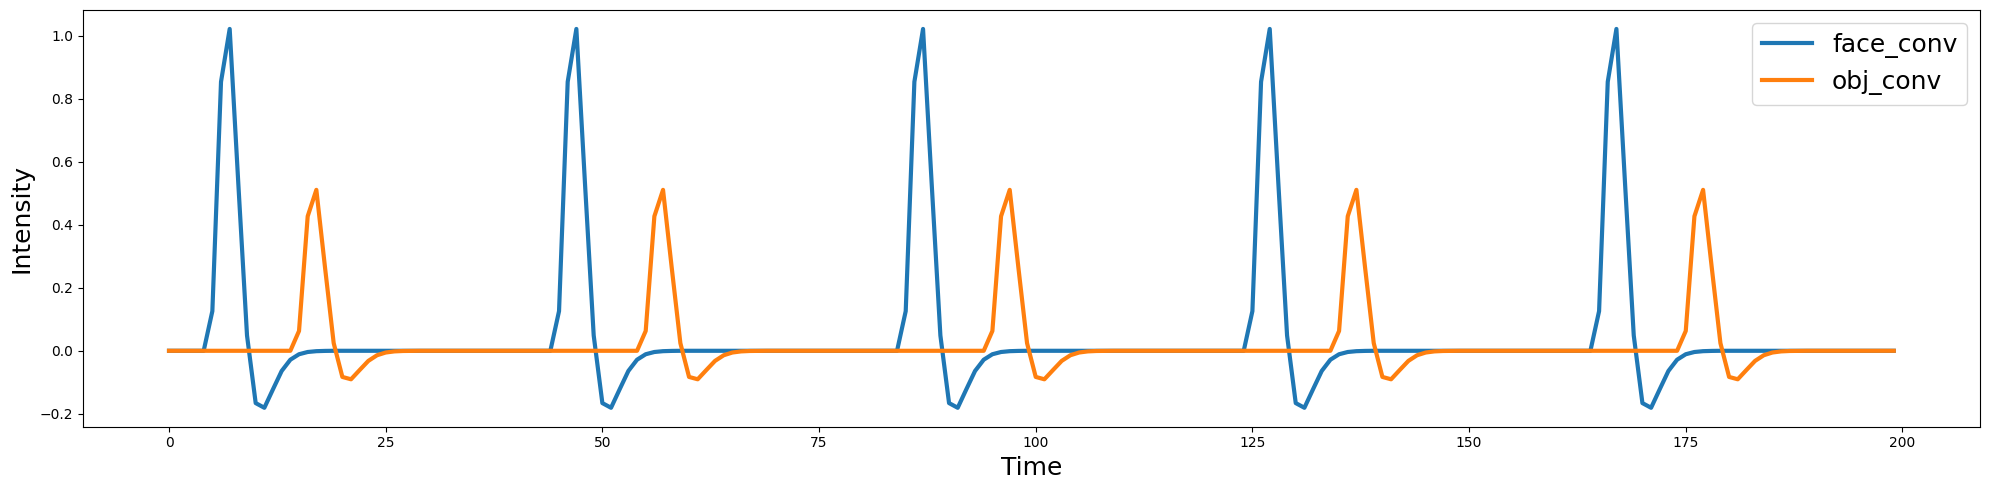

In [154]:
# convolve the actual data with the hrf
face_conv=np.convolve(face,hrf, mode="same") #mode save ensures same length for everything
obj_conv=np.convolve(obj, hrf, mode="same")
voxel_conv=np.vstack([face_conv,obj_conv]).T
plot_timeseries(voxel_conv,labels=["face_conv","obj_conv"])

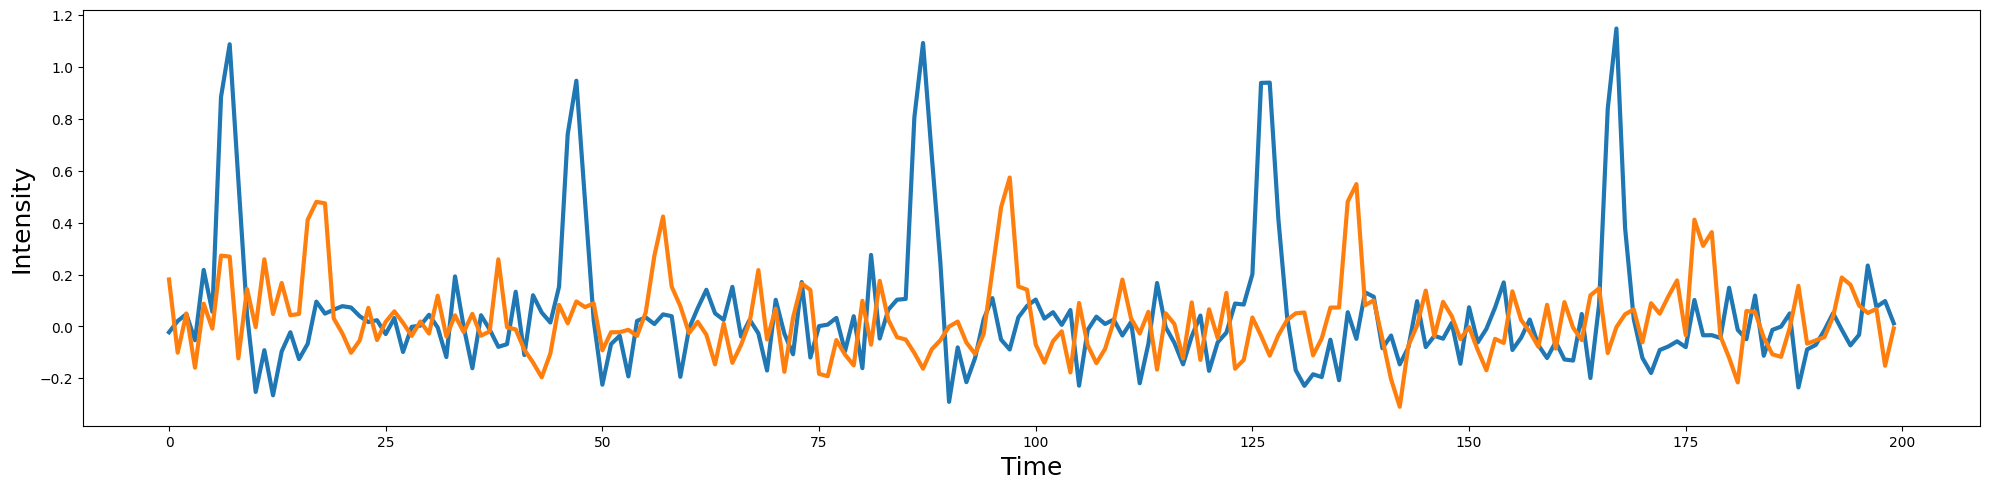

In [155]:
#adding noise
sigma=0.1
epsilon=sigma*np.random.randn(n_tr,2) #matrix with n_tr rows, 2 columns
voxel_conv_noise=voxel_conv+epsilon
plot_timeseries(voxel_conv_noise)


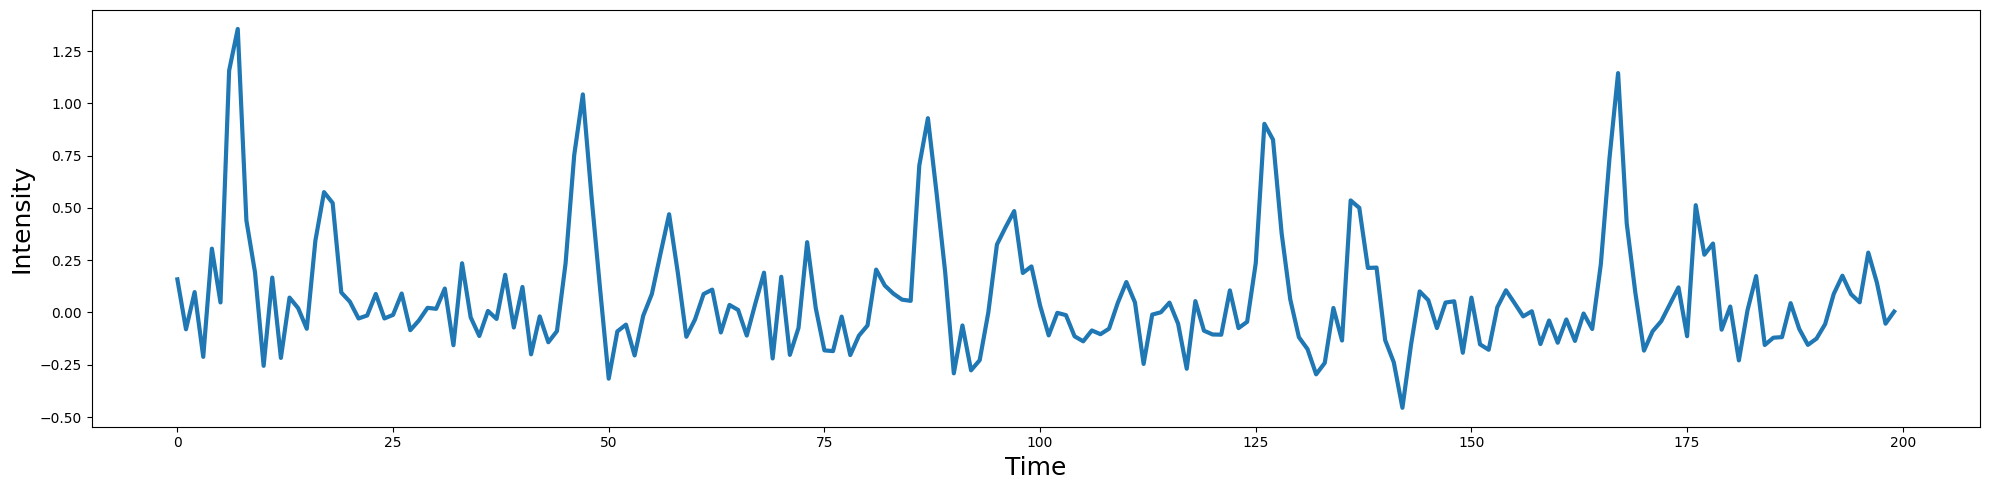

In [156]:
# remember, one signal represents face activation, the other object. In a bold signal, we wouldn't see two separate
# we see one activity that conscitutes many underlying activities. Add the waves 
# Y is our simulated voxel timeseries
Y=voxel_conv_noise.sum(axis=1) #sum columns 
plot_timeseries(Y)

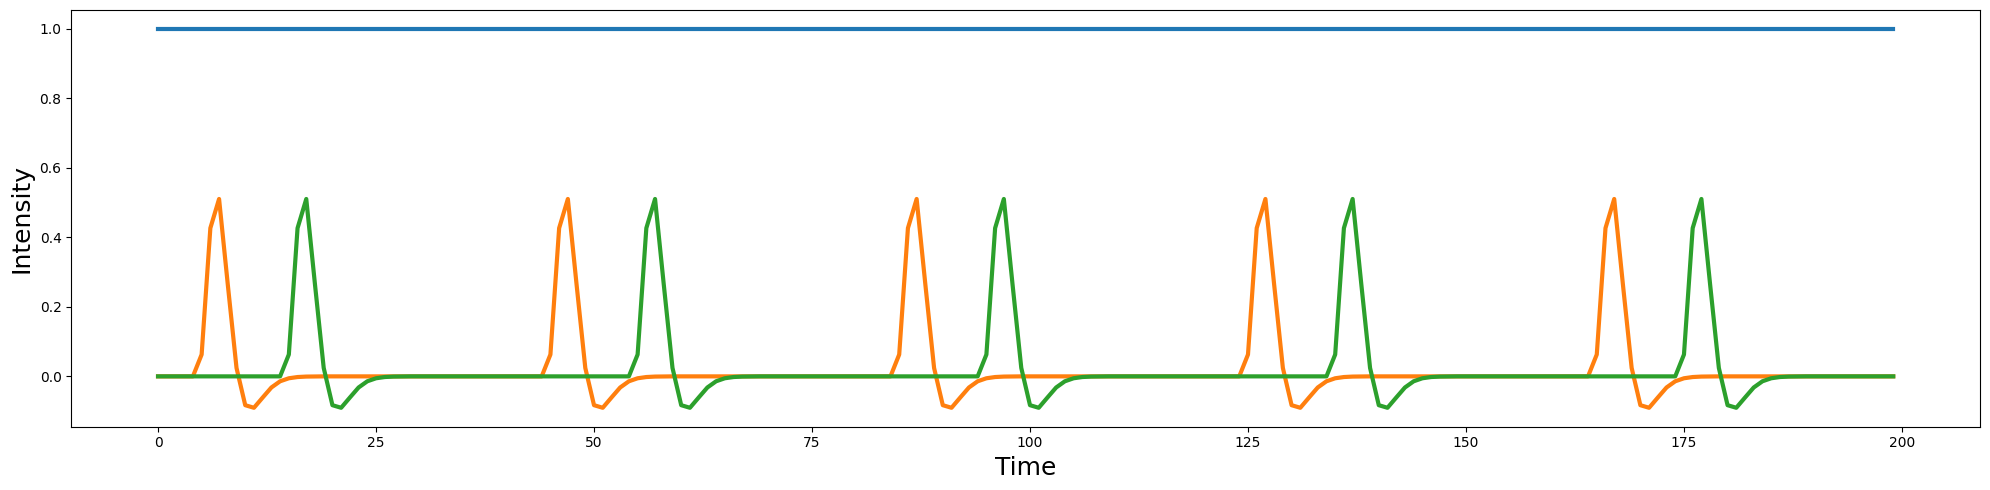

In [157]:
# now we have a signla that constitutes multiple underlying signals (that we aren't supposed to know of)
# lets design a design matrix, and check if GLM can recover original signal
#  Y = XB + e

#intercept
n_tr = 200
n_trial = 5
face = np.zeros(n_tr)
face[np.arange(10, n_tr, int(n_tr/n_trial))] = 1
obj = np.zeros(n_tr)
obj[np.arange(20, n_tr, int(n_tr/n_trial))] = 1
intercept = np.ones(n_tr)
X = np.vstack([intercept, np.convolve(face, hrf, mode='same'), np.convolve(obj, hrf, mode='same')]).T

plot_timeseries(X)

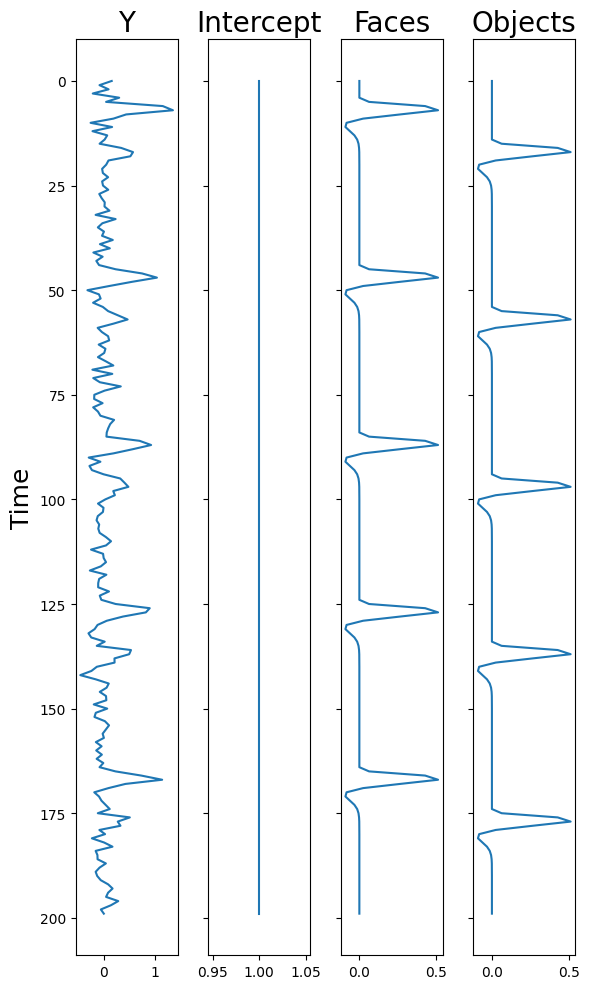

In [158]:
# model:
# Voxel = B_0 * intercept + B_1 * face_conv + B_2 * obj_conv + e
# lets invert the axis and plot subplots (getting closer to design matrix)
f, a = plt.subplots(ncols=4, figsize=(6, 10), sharey=True)
a[0].plot(np.expand_dims(Y, axis=1), range(len(Y)))
a[1].plot(X[:,0], range(len(Y)))
a[2].plot(X[:,1], range(len(Y)))
a[3].plot(X[:,2], range(len(Y)))
a[0].set_ylabel('Time', fontsize=18)
a[0].set_title('Y', fontsize=20)
a[1].set_title('Intercept', fontsize=20)
a[2].set_title('Faces', fontsize=20)
a[3].set_title('Objects', fontsize=20)
plt.gca().invert_yaxis()
plt.tight_layout()

beta Faces - beta Objects: 1.1


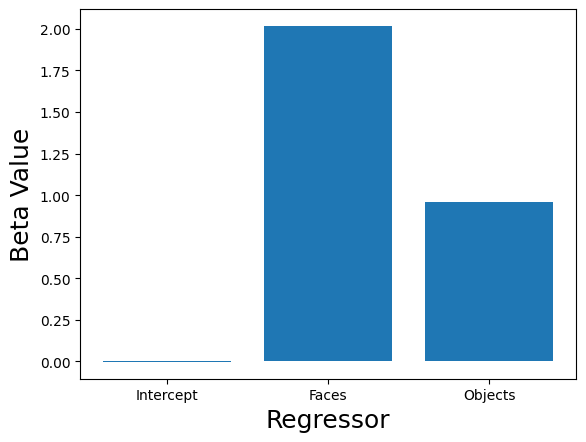

In [159]:
# returns estimate Beta
def ols_estimator(X, Y):
    return np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), Y)

beta = ols_estimator(X, Y)

plt.bar(['Intercept','Faces', 'Objects'], beta)
plt.xlabel('Regressor', fontsize=18)
plt.ylabel('Beta Value', fontsize=18)

print(f'beta Faces - beta Objects: {beta[1]-beta[2]:.2}')

Text(0.5, 1.0, 'Residual')

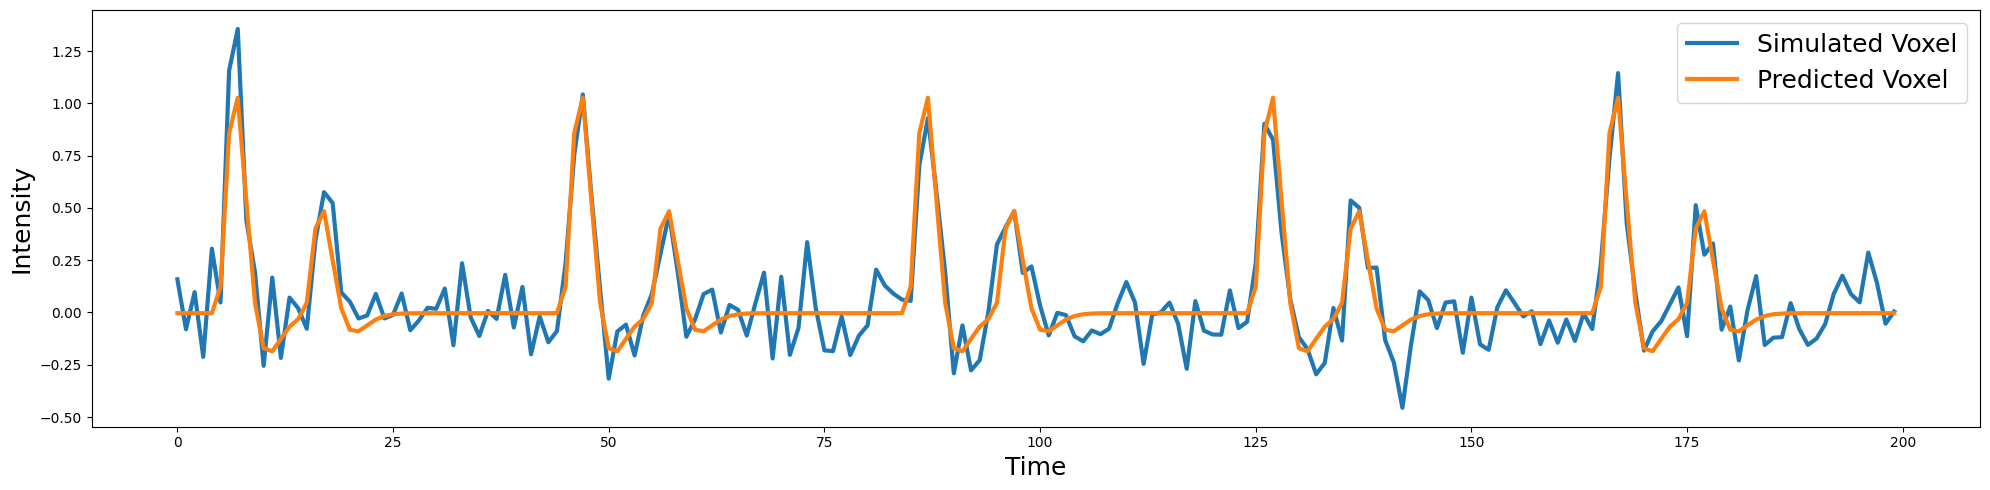

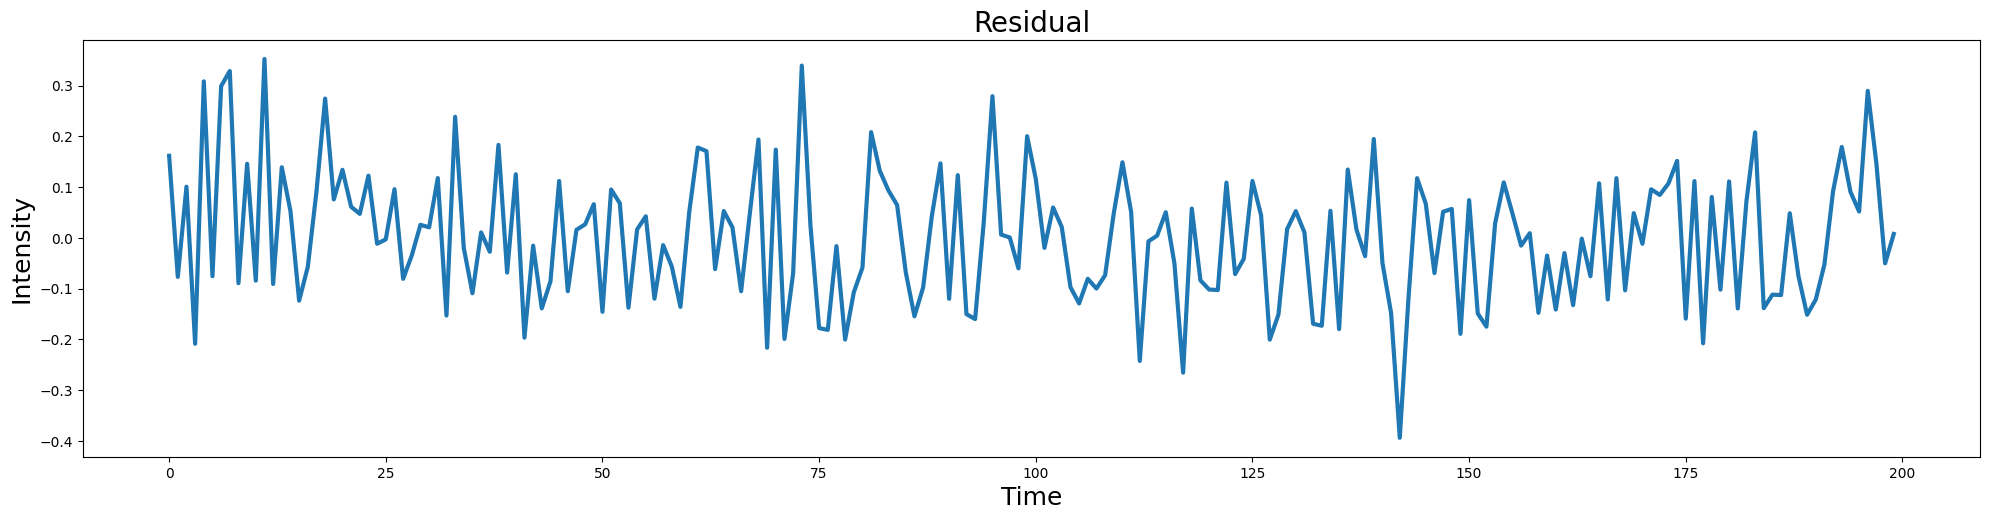

In [160]:
predicted_y = np.dot(X, beta)
predicted_ts = np.vstack([Y, predicted_y]).T
plot_timeseries(predicted_ts, labels=['Simulated Voxel', 'Predicted Voxel'])
residual = Y - predicted_y
plot_timeseries(residual)
plt.title('Residual', fontsize=20)

standard error: 0.12939797110713747


(array([ 1.,  1., 14., 39., 32., 48., 36., 18.,  4.,  7.]),
 array([-0.3942041 , -0.31952774, -0.24485139, -0.17017503, -0.09549867,
        -0.02082231,  0.05385405,  0.12853041,  0.20320677,  0.27788313,
         0.35255949]),
 <BarContainer object of 10 artists>)

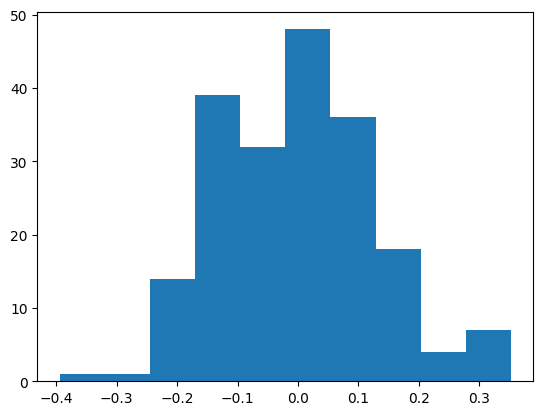

In [161]:
standard_error_estimate=np.std(residual)
print(f"standard error: {standard_error_estimate}")
plt.hist(residual)

In [162]:
# explained variance
def r_square(Y, predicted_y):
    SS_total = np.sum((Y - np.mean(Y))**2)
    SS_residual = np.sum((Y - predicted_y)**2)
    return 1-(SS_residual/SS_total)

print(f"R^2: {r_square(Y, predicted_y):.2}")

R^2: 0.79


Text(0, 0.5, 'Beta Value')

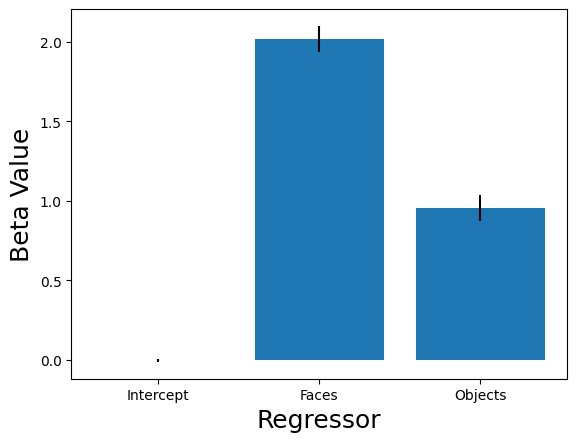

In [163]:
# standard error estimate is the standard deviation of the residual. So the model estimates a fit, and 
# we get standard deviation of error estimate from the residuals. 
# we estimate the a confidence interval of Beta coefficients by the formula 
std_error = np.sqrt(np.diag((np.linalg.pinv(np.dot(X.T, X))))) * standard_error_estimate
# if standard error estimates were higher, the confidence interval becomes wider. (we don't want it)

plt.bar(['Intercept','Faces', 'Objects'], beta, yerr = std_error)
plt.xlabel('Regressor', fontsize=18)
plt.ylabel('Beta Value', fontsize=18)

[-0.34135885 24.92275998 11.81829192]
[7.33193618e-01 4.12519148e-63 9.20693433e-25]


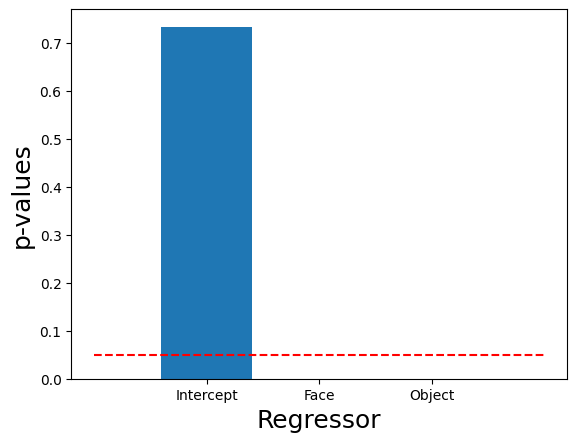

In [164]:
# evaluate if any regressors are statistically different than zero
t_stat=beta/std_error
print(t_stat)
# calculate p-val
from scipy import stats

p = stats.t.sf(np.abs(t_stat), n_tr-1)*2
print(p)

plt.bar(['Intercept', 'Face', 'Object'], p)
plt.ylabel('p-values', fontsize=18)
plt.xlabel('Regressor', fontsize=18)
plt.hlines(0.05, -1, 3, linestyles='dashed', color='red')